Fixed sigma ratio: σ2/σ1 = 0.7883 (= 35.0/44.4)
(Closer collimator sees larger apparent size)

=== Simultaneous Optimization Results ===
Dataset 1 (Collimator at 35.0 cm from source):
  Weight (w1):        0.0390 ± 0.0060 (3.90%)
  Apparent σ1:        4.375 ± 0.355 cm

Dataset 2 (Collimator at 44.4 cm from source):
  Weight (w2):        0.0579 ± 0.0071 (5.79%)
  Apparent σ2:        3.448 cm (constrained = σ1 × 0.7883)

=== Physical Interpretation ===
Implied physical source size (d):
  From dataset 1:     153.110 cm
  From dataset 2:     153.110 cm
  (Should be identical due to constraint)

Verification: σ2/σ1 = 0.7883 (target: 0.7883)


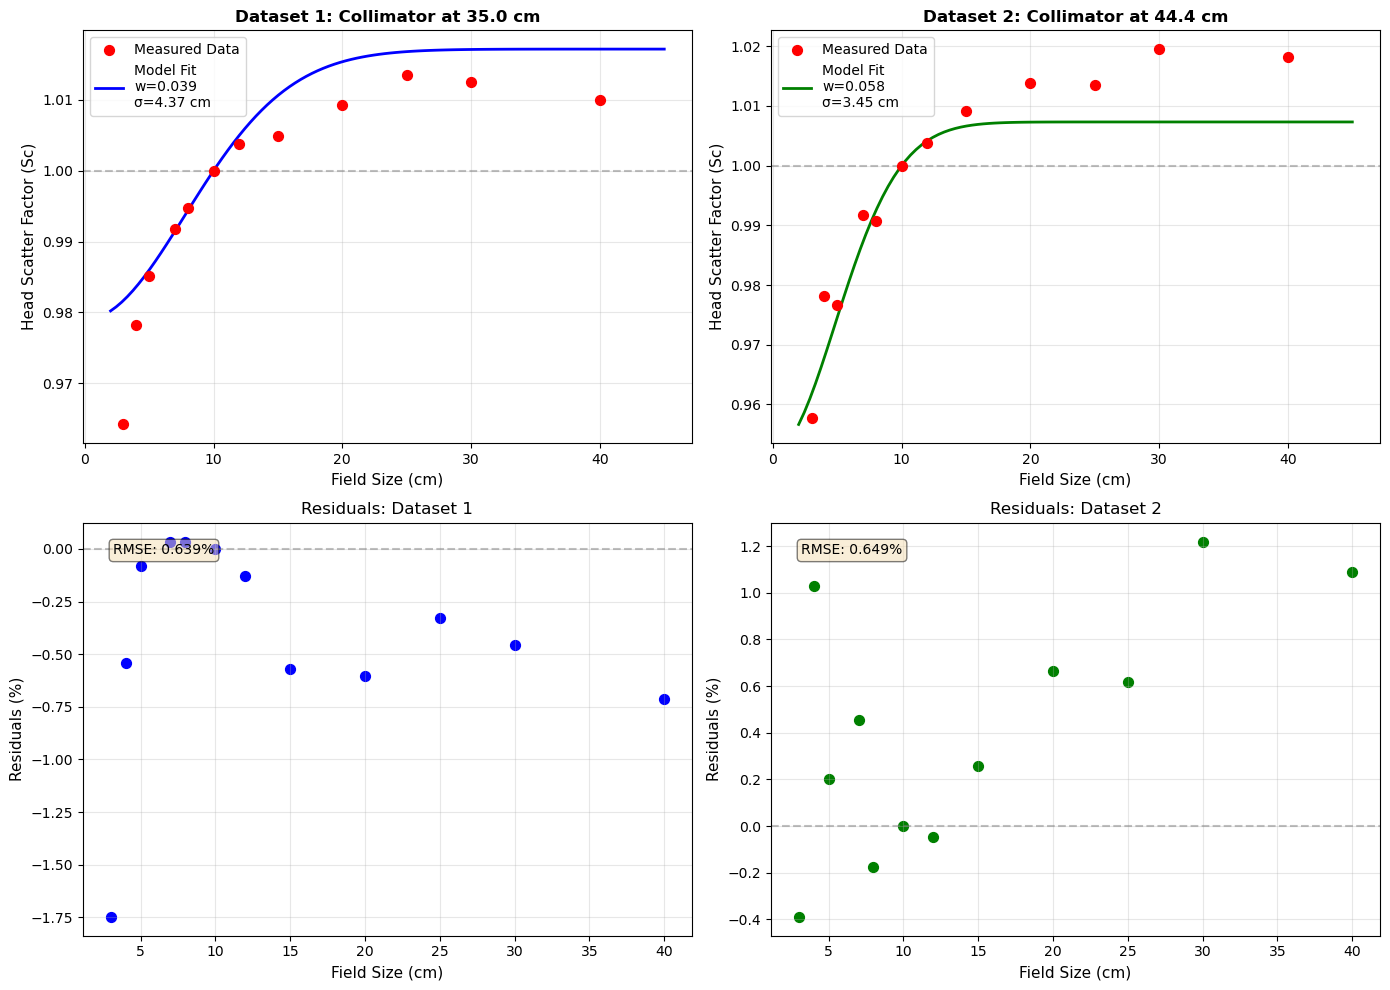


=== Fit Quality ===
Dataset 1 RMSE: 0.6388%
Dataset 2 RMSE: 0.6494%
Combined RMSE: 0.6441%


In [11]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.special import erf
import matplotlib.pyplot as plt

# --- 1. THE DATA ---
# Dataset 1: Collimator at 35 cm from source
raw_data_1 = np.array([
    [3,  0.9642], [4,  0.9782], [5,  0.9852], [7,  0.9918], 
    [8,  0.9947], [10, 1.0000], [12, 1.0037], [15, 1.0049], 
    [20, 1.0093], [25, 1.0135], [30, 1.0125], [40, 1.0100]
])

# Dataset 2: Collimator at 44.4 cm from source
raw_data_2 = np.array([
    [3,  0.9578], [4,  0.9782], [5,  0.9766], [7,  0.9918], 
    [8,  0.9907], [10, 1.0000], [12, 1.0037], [15, 1.0092], 
    [20, 1.0139], [25, 1.0135], [30, 1.0195], [40, 1.0182]
])

field_sizes_1 = raw_data_1[:, 0]
measured_sc_1 = raw_data_1[:, 1]

field_sizes_2 = raw_data_2[:, 0]
measured_sc_2 = raw_data_2[:, 1]

# Physical setup
COLLIMATOR_DISTANCE_1 = 35.0  # cm from source
COLLIMATOR_DISTANCE_2 = 44.4  # cm from source
SOURCE_TO_ISO = 100.0  # cm

# The constraint: For the same physical object size d:
# σ1 = d / distance_1
# σ2 = d / distance_2
# Therefore: σ2 / σ1 = distance_1 / distance_2 (INVERSE ratio!)
SIGMA_RATIO = COLLIMATOR_DISTANCE_1 / COLLIMATOR_DISTANCE_2

print(f"Fixed sigma ratio: σ2/σ1 = {SIGMA_RATIO:.4f} (= {COLLIMATOR_DISTANCE_1}/{COLLIMATOR_DISTANCE_2})")
print(f"(Closer collimator sees larger apparent size)")

# --- 2. THE PHYSICS MODEL ---
def sc_model(s, collimator_distance, w, sigma):
    """
    s: Field Size at isocenter (cm)
    collimator_distance: Distance from source to collimator (cm)
    w: Weight of scatter source (relative to primary)
    sigma: Apparent width of scatter source as seen from this collimator (cm)
    """
    # Project field size back to the collimator plane
    s_projected = s * (collimator_distance / SOURCE_TO_ISO)
    
    # The 'View Factor' (Integral of Gaussian through square aperture)
    view_factor = (erf(s_projected / sigma))**2
    
    # Calculate Raw Intensity (Primary + Weighted Scatter)
    raw_intensity = 1.0 + (w * view_factor)
    
    # Normalize to 10x10 Field (Reference)
    ref_s_projected = 10.0 * (collimator_distance / SOURCE_TO_ISO)
    ref_view_factor = (erf(ref_s_projected / sigma))**2
    ref_intensity = 1.0 + (w * ref_view_factor)
    
    return raw_intensity / ref_intensity


def combined_model(field_sizes_combined, w1, sigma1, w2):
    """
    Combined model for both datasets simultaneously
    Parameters:
      w1: weight for dataset 1
      sigma1: apparent sigma for dataset 1 (at distance_1)
      w2: weight for dataset 2
    Note: sigma2 is computed as sigma1 * (distance_1/distance_2) (constraint)
    """
    n1 = len(field_sizes_1)
    
    # Split the input
    s1 = field_sizes_combined[:n1]
    s2 = field_sizes_combined[n1:]
    
    # Apply the constraint: sigma2 is fixed relative to sigma1
    # Same physical object, different viewing distance
    sigma2 = sigma1 * SIGMA_RATIO
    
    # Calculate model for each dataset
    result_1 = sc_model(s1, COLLIMATOR_DISTANCE_1, w1, sigma1)
    result_2 = sc_model(s2, COLLIMATOR_DISTANCE_2, w2, sigma2)
    
    return np.concatenate([result_1, result_2])


# --- 3. THE OPTIMIZATION ---
# Combine the data
field_sizes_combined = np.concatenate([field_sizes_1, field_sizes_2])
measured_sc_combined = np.concatenate([measured_sc_1, measured_sc_2])

# Initial Guesses: w1=0.05, sigma1=5.0, w2=0.05
p0 = [0.05, 5.0, 0.05]

# Run the optimizer
popt, pcov = curve_fit(combined_model, field_sizes_combined, measured_sc_combined, p0=p0)
fitted_w1, fitted_sigma1, fitted_w2 = popt
fitted_sigma2 = fitted_sigma1 * SIGMA_RATIO

# Calculate the implied physical size of the scatter source
# d = sigma1 * distance_1 = sigma2 * distance_2
physical_size_from_1 = fitted_sigma1 * COLLIMATOR_DISTANCE_1
physical_size_from_2 = fitted_sigma2 * COLLIMATOR_DISTANCE_2

# Calculate standard errors
perr = np.sqrt(np.diag(pcov))

# --- 4. RESULTS & VISUALIZATION ---
print(f"\n=== Simultaneous Optimization Results ===")
print(f"Dataset 1 (Collimator at {COLLIMATOR_DISTANCE_1} cm from source):")
print(f"  Weight (w1):        {fitted_w1:.4f} ± {perr[0]:.4f} ({fitted_w1*100:.2f}%)")
print(f"  Apparent σ1:        {fitted_sigma1:.3f} ± {perr[1]:.3f} cm")
print(f"\nDataset 2 (Collimator at {COLLIMATOR_DISTANCE_2} cm from source):")
print(f"  Weight (w2):        {fitted_w2:.4f} ± {perr[2]:.4f} ({fitted_w2*100:.2f}%)")
print(f"  Apparent σ2:        {fitted_sigma2:.3f} cm (constrained = σ1 × {SIGMA_RATIO:.4f})")
print(f"\n=== Physical Interpretation ===")
print(f"Implied physical source size (d):")
print(f"  From dataset 1:     {physical_size_from_1:.3f} cm")
print(f"  From dataset 2:     {physical_size_from_2:.3f} cm")
print(f"  (Should be identical due to constraint)")
print(f"\nVerification: σ2/σ1 = {fitted_sigma2/fitted_sigma1:.4f} (target: {SIGMA_RATIO:.4f})")

# Generate smooth curves for plotting
s_smooth = np.linspace(2, 45, 100)
sc_smooth_1 = sc_model(s_smooth, COLLIMATOR_DISTANCE_1, fitted_w1, fitted_sigma1)
sc_smooth_2 = sc_model(s_smooth, COLLIMATOR_DISTANCE_2, fitted_w2, fitted_sigma2)

# Calculate residuals
residuals_1 = measured_sc_1 - sc_model(field_sizes_1, COLLIMATOR_DISTANCE_1, fitted_w1, fitted_sigma1)
residuals_2 = measured_sc_2 - sc_model(field_sizes_2, COLLIMATOR_DISTANCE_2, fitted_w2, fitted_sigma2)

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Dataset 1
axes[0, 0].scatter(field_sizes_1, measured_sc_1, color='red', s=50, label='Measured Data', zorder=3)
axes[0, 0].plot(s_smooth, sc_smooth_1, color='blue', linewidth=2, 
                label=f'Model Fit\nw={fitted_w1:.3f}\nσ={fitted_sigma1:.2f} cm')
axes[0, 0].axhline(1.0, linestyle='--', color='gray', alpha=0.5)
axes[0, 0].set_xlabel('Field Size (cm)', fontsize=11)
axes[0, 0].set_ylabel('Head Scatter Factor (Sc)', fontsize=11)
axes[0, 0].set_title(f'Dataset 1: Collimator at {COLLIMATOR_DISTANCE_1} cm', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Dataset 2
axes[0, 1].scatter(field_sizes_2, measured_sc_2, color='red', s=50, label='Measured Data', zorder=3)
axes[0, 1].plot(s_smooth, sc_smooth_2, color='green', linewidth=2, 
                label=f'Model Fit\nw={fitted_w2:.3f}\nσ={fitted_sigma2:.2f} cm')
axes[0, 1].axhline(1.0, linestyle='--', color='gray', alpha=0.5)
axes[0, 1].set_xlabel('Field Size (cm)', fontsize=11)
axes[0, 1].set_ylabel('Head Scatter Factor (Sc)', fontsize=11)
axes[0, 1].set_title(f'Dataset 2: Collimator at {COLLIMATOR_DISTANCE_2} cm', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Residuals Dataset 1
axes[1, 0].scatter(field_sizes_1, residuals_1 * 100, color='blue', s=50)
axes[1, 0].axhline(0, linestyle='--', color='gray', alpha=0.5)
axes[1, 0].set_xlabel('Field Size (cm)', fontsize=11)
axes[1, 0].set_ylabel('Residuals (%)', fontsize=11)
axes[1, 0].set_title('Residuals: Dataset 1', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)
rmse_1 = np.sqrt(np.mean(residuals_1**2)) * 100
axes[1, 0].text(0.05, 0.95, f'RMSE: {rmse_1:.3f}%', 
                transform=axes[1, 0].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 4: Residuals Dataset 2
axes[1, 1].scatter(field_sizes_2, residuals_2 * 100, color='green', s=50)
axes[1, 1].axhline(0, linestyle='--', color='gray', alpha=0.5)
axes[1, 1].set_xlabel('Field Size (cm)', fontsize=11)
axes[1, 1].set_ylabel('Residuals (%)', fontsize=11)
axes[1, 1].set_title('Residuals: Dataset 2', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)
rmse_2 = np.sqrt(np.mean(residuals_2**2)) * 100
axes[1, 1].text(0.05, 0.95, f'RMSE: {rmse_2:.3f}%', 
                transform=axes[1, 1].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print detailed statistics
print(f"\n=== Fit Quality ===")
print(f"Dataset 1 RMSE: {rmse_1:.4f}%")
print(f"Dataset 2 RMSE: {rmse_2:.4f}%")
print(f"Combined RMSE: {np.sqrt(np.mean(np.concatenate([residuals_1, residuals_2])**2)) * 100:.4f}%")